In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
import pylab as pl
from IPython import display
import time
import random
import scipy.fftpack
from mpl_toolkits.mplot3d import Axes3D
from scipy import signal
from scipy import interpolate

## How the 2D FFT works

### Reusable functions

In [2]:
def make_hypercube(start, end, freq, phase):

    # shape the spatial variables
    coords = np.arange(start, end)
    length = len(coords)
    y = coords.reshape(1, 1, length, 1)
    x = coords.reshape(1, 1, 1, length)

    # shape the spectral variables
    if isinstance(freq, (int, float)):
        freq = np.array([freq])
    if isinstance(phase, (int, float)):
        phase = np.array([phase])
    freq = freq.reshape(len(freq), 1, 1, 1)
    phase = phase.reshape(1, len(phase), 1, 1)

    xp = (y * np.cos(phase)) + (x * np.sin(phase))
    return np.sin(2 * np.pi * freq * xp)

In [3]:
def extract_power_angle(space_cube, axes=(-2, -1)):

    # 2D FFT, shift low frequencies to the center
    freq_cube = scipy.fftpack.fftshift(
        scipy.fftpack.fft2(space_cube, axes=axes),
        axes=axes
        )
    
    return np.abs(freq_cube), np.angle(freq_cube)

In [4]:
def plot_cube(space_cube, power_cube, phase_cube, start=61, end=121, itp="nearest", wait=.01):

    # Makr a mosaic figure
    canvas = plt.figure()
    panels = canvas.subplot_mosaic([
        ["Space domain", "Amplitude spectrum"],
        ["Space domain", "Phase spectrum"]
        ])

    # Set the panel styles
    for panel_name, panel in panels.items():
        panel.set_title(panel_name)
        panel.axis("off");

    # plot
    for slice_idx in range(space_cube.shape[0]):
        
        # show original image
        panels["Space domain"].imshow(
            space_cube[slice_idx, :, :],
            interpolation=itp
            )
        
        # show amplitude spectrum
        panels["Amplitude spectrum"].imshow(
            power_cube[slice_idx, start:end, start:end],
            interpolation=itp
            )
        
        # show phase spectrum
        panels["Phase spectrum"].imshow(
            phase_cube[slice_idx, start:end, start:end],
            interpolation=itp
            )
        
        display.display(canvas)
        display.clear_output(wait=True)
        
        time.sleep(wait)

### Plot changing frequency

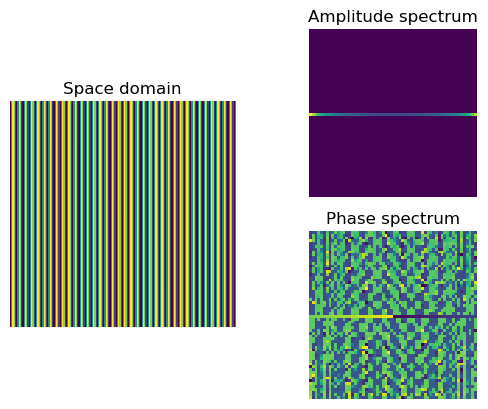

In [5]:
change_freq = (
    make_hypercube(
        start=-91,
        end=91,
        freq=np.linspace(.0001, .2, 50),
        phase=np.pi/2
        )
    .squeeze()
    )

plot_cube(change_freq, *extract_power_angle(change_freq))

### Plot changing the phase

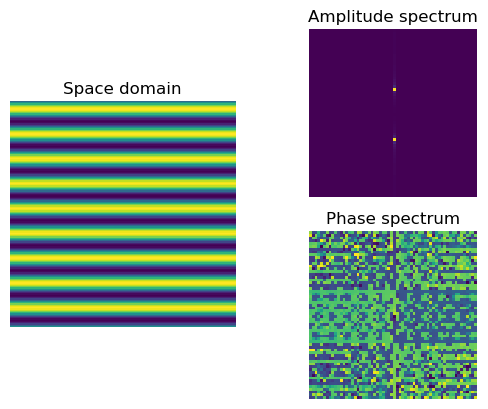

In [6]:
change_freq = (
    make_hypercube(
        start=-91,
        end=91,
        freq=.05,
        phase=np.linspace(0,np.pi,50)
        )
    .squeeze()
    )

plot_cube(change_freq, *extract_power_angle(change_freq))

### Plot changing both

In [7]:
# Prepare the coordinates
lims  = [-91,91]
coords = np.arange(*lims)
[_, y, x] = np.meshgrid(np.ones(1), coords, coords, indexing="ij")

# width and successive centers of the gaussian
width = 20 # width of Gaussian
centlocs = np.linspace(-80,80,50).reshape(50, 1, 1)

# create Gaussian
mx = x-centlocs
my = y-20
gauss2d = np.exp( -( mx**2 + my**2 ) / (2*width**2) )

# Mask
is_high = (gauss2d > .9)

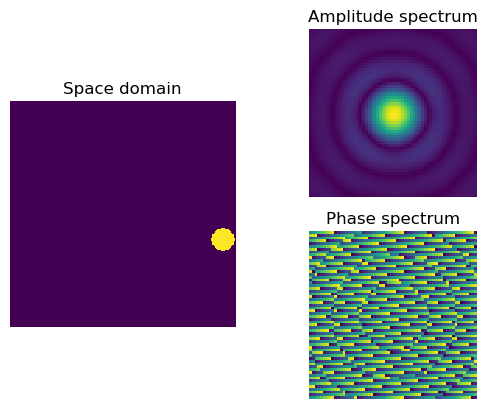

In [8]:
plot_cube(is_high, *extract_power_angle(is_high))